In [1]:
import pandas as pd
import numpy as np
import akshare as ak
from utils import to_baostock_code, load_or_fetch
from plot_setup import setup_chinese_font

SEED = 2026
START_DATE = "2023-04-17"
END_DATE = "2026-04-17"

In [2]:
# 沪深300 constituents
hs300 = ak.index_stock_cons(symbol="000300")
print(f"沪深300 has {len(hs300)} constituents")
print(hs300.head())

# 中证1000 constituents
zz1000 = ak.index_stock_cons(symbol="000852")
print(f"中证1000 has {len(zz1000)} constituents")
print(zz1000.head())

沪深300 has 300 constituents
     品种代码  品种名称        纳入日期
0  002625  光启技术  2025-12-15
1  300476  胜宏科技  2025-12-15
2  300251  光线传媒  2025-12-15
3  002384  东山精密  2025-12-15
4  603893   瑞芯微  2025-12-15
中证1000 has 1000 constituents
     品种代码  品种名称        纳入日期
0  688486  龙迅股份  2026-02-05
1  301101  明月镜片  2026-01-12
2  300573  兴齐眼药  2025-12-15
3  300131  英唐智控  2025-12-15
4  301018  申菱环境  2025-12-15


In [3]:
rng = np.random.default_rng(SEED)

hs300_sample = hs300.sample(n=5, random_state=rng).reset_index(drop=True)
zz1000_sample = zz1000.sample(n=5, random_state=rng).reset_index(drop=True)

print("沪深300 sample:")
print(hs300_sample[["品种代码", "品种名称", "纳入日期"]])
print("\n中证1000 sample:")
print(zz1000_sample[["品种代码", "品种名称", "纳入日期"]])

沪深300 sample:
     品种代码  品种名称        纳入日期
0  601211  国泰君安  2015-12-14
1  601995  中金公司  2021-06-15
2  688256   寒武纪  2023-12-11
3  000876   新希望  2007-07-02
4  600522  中天科技  2025-12-15

中证1000 sample:
     品种代码  品种名称        纳入日期
0  300348  长亮科技  2015-12-14
1  002020  京新药业  2018-06-11
2  600761  安徽合力  2019-06-17
3  688433  华曙高科  2024-06-17
4  000848  承德露露  2020-12-14


In [4]:
hs300_codes = [to_baostock_code(c) for c in hs300_sample["品种代码"]]
zz1000_codes = [to_baostock_code(c) for c in zz1000_sample["品种代码"]]

print("沪深300 codes:", hs300_codes)
print("中证1000 codes:", zz1000_codes)

hs300_data = {}
for code, name in zip(hs300_codes, hs300_sample["品种名称"]):
    print(f"Pulling {code} ({name})...")
    hs300_data[code] = load_or_fetch(code, START_DATE, END_DATE)
    print(f"  {len(hs300_data[code])} rows")

zz1000_data = {}
for code, name in zip(zz1000_codes, zz1000_sample["品种名称"]):
    print(f"Pulling {code} ({name})...")
    zz1000_data[code] = load_or_fetch(code, START_DATE, END_DATE)
    print(f"  {len(zz1000_data[code])} rows")

沪深300 codes: ['sh.601211', 'sh.601995', 'sh.688256', 'sz.000876', 'sh.600522']
中证1000 codes: ['sz.300348', 'sz.002020', 'sh.600761', 'sh.688433', 'sz.000848']
Pulling sh.601211 (国泰君安)...
  727 rows
Pulling sh.601995 (中金公司)...
  727 rows
Pulling sh.688256 (寒武纪)...
  727 rows
Pulling sz.000876 (新希望)...
  727 rows
Pulling sh.600522 (中天科技)...
  727 rows
Pulling sz.300348 (长亮科技)...
  727 rows
Pulling sz.002020 (京新药业)...
  727 rows
Pulling sh.600761 (安徽合力)...
  727 rows
Pulling sh.688433 (华曙高科)...
  727 rows
Pulling sz.000848 (承德露露)...
  727 rows


In [5]:
# Check date alignment across all stocks
all_data = {**hs300_data, **zz1000_data}

first_dates = {code: df.index.min() for code, df in all_data.items()}
last_dates = {code: df.index.max() for code, df in all_data.items()}

print("First dates:")
for code, date in first_dates.items():
    print(f"  {code}: {date.date()}")
print("\nLast dates:")
for code, date in last_dates.items():
    print(f"  {code}: {date.date()}")

First dates:
  sh.601211: 2023-04-17
  sh.601995: 2023-04-17
  sh.688256: 2023-04-17
  sz.000876: 2023-04-17
  sh.600522: 2023-04-17
  sz.300348: 2023-04-17
  sz.002020: 2023-04-17
  sh.600761: 2023-04-17
  sh.688433: 2023-04-17
  sz.000848: 2023-04-17

Last dates:
  sh.601211: 2026-04-17
  sh.601995: 2026-04-17
  sh.688256: 2026-04-17
  sz.000876: 2026-04-17
  sh.600522: 2026-04-17
  sz.300348: 2026-04-17
  sz.002020: 2026-04-17
  sh.600761: 2026-04-17
  sh.688433: 2026-04-17
  sz.000848: 2026-04-17


In [6]:
import matplotlib.pyplot as plt

# Pick one stock to examine first
code = "sh.688256"
name = "寒武纪"
df = all_data[code]

# Compute log returns
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

# Compute 20-day rolling std
df["rolling_vol_20"] = df["log_return"].rolling(window=20).std()

# Preview
print(df[["close", "log_return", "rolling_vol_20"]].head(25))

             close  log_return  rolling_vol_20
date                                          
2023-04-17  196.80         NaN             NaN
2023-04-18  195.78   -0.005196             NaN
2023-04-19  221.80    0.124784             NaN
2023-04-20  266.16    0.182322             NaN
2023-04-21  248.00   -0.070669             NaN
2023-04-24  243.00   -0.020367             NaN
2023-04-25  248.00    0.020367             NaN
2023-04-26  238.00   -0.041158             NaN
2023-04-27  230.75   -0.030936             NaN
2023-04-28  249.50    0.078124             NaN
2023-05-04  232.80   -0.069279             NaN
2023-05-05  207.98   -0.112738             NaN
2023-05-08  208.39    0.001969             NaN
2023-05-09  211.40    0.014341             NaN
2023-05-10  199.08   -0.060045             NaN
2023-05-11  196.02   -0.015490             NaN
2023-05-12  196.00   -0.000102             NaN
2023-05-15  188.45   -0.039282             NaN
2023-05-16  184.51   -0.021129             NaN
2023-05-17  1

In [7]:
print(df.loc["2023-04-19":"2023-04-21", ["open", "high", "low", "close", "pctChg"]])

              open    high     low   close   pctChg
date                                               
2023-04-19  204.50  223.28  204.50  221.80  13.2904
2023-04-20  230.06  266.16  230.06  266.16  20.0000
2023-04-21  271.40  271.47  243.00  248.00  -6.8230


In [8]:
from utils import detect_limit_hits

# Test on April 20 day
test_ret = df["log_return"].loc["2023-04-19":"2023-04-21"]
print("Log returns for these days:")
print(test_ret)
print()

flags = detect_limit_hits(test_ret, codes="sh.688256")
print("Limit hit flags:")
print(flags)

Log returns for these days:
date
2023-04-19    0.124784
2023-04-20    0.182322
2023-04-21   -0.070669
Name: log_return, dtype: float64

Limit hit flags:
            limit_up  limit_down
date                            
2023-04-19     False       False
2023-04-20      True       False
2023-04-21     False       False


In [9]:
import importlib
import utils
importlib.reload(utils)
from utils import detect_limit_hits

# Retest on April 20
test_ret = df["log_return"].loc["2023-04-19":"2023-04-21"]
flags = detect_limit_hits(test_ret, codes="sh.688256")
print(flags)

            limit_up  limit_down
date                            
2023-04-19     False       False
2023-04-20      True       False
2023-04-21     False       False


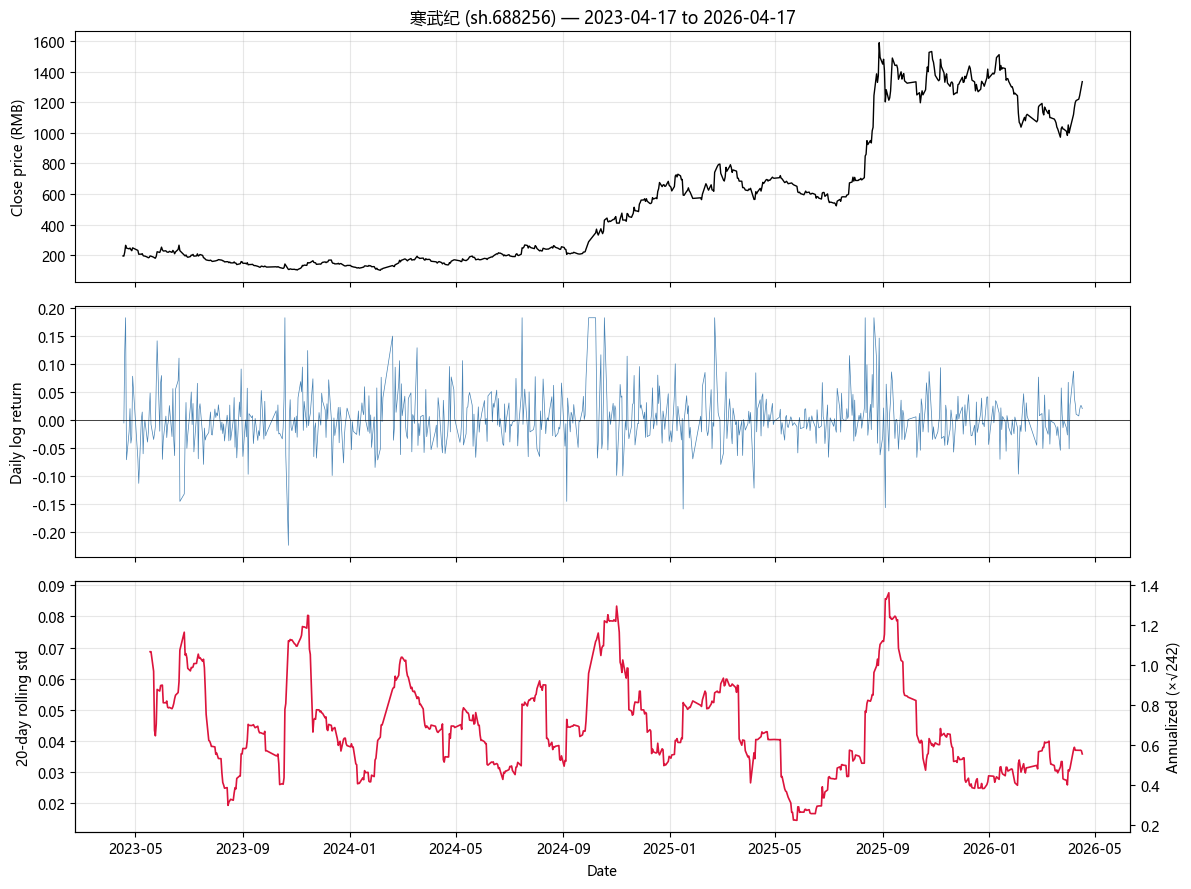

In [10]:
setup_chinese_font()
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Panel 1: price
axes[0].plot(df.index, df["close"], color="black", linewidth=1)
axes[0].set_ylabel("Close price (RMB)")
axes[0].set_title(f"{name} ({code}) — 2023-04-17 to 2026-04-17")
axes[0].grid(alpha=0.3)

# Panel 2: daily log returns
axes[1].plot(df.index, df["log_return"], color="steelblue", linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Daily log return")
axes[1].grid(alpha=0.3)

# Panel 3: 20-day rolling volatility
axes[2].plot(df.index, df["rolling_vol_20"], color="crimson", linewidth=1.2)
axes[2].set_ylabel("20-day rolling std")
axes[2].set_xlabel("Date")
axes[2].grid(alpha=0.3)

# Annualized vol on a secondary y-axis for intuition
ax2_right = axes[2].twinx()
ax2_right.plot(df.index, df["rolling_vol_20"] * np.sqrt(242), color="crimson", alpha=0)
ax2_right.set_ylabel("Annualized (×√242)")

plt.tight_layout()
plt.show()

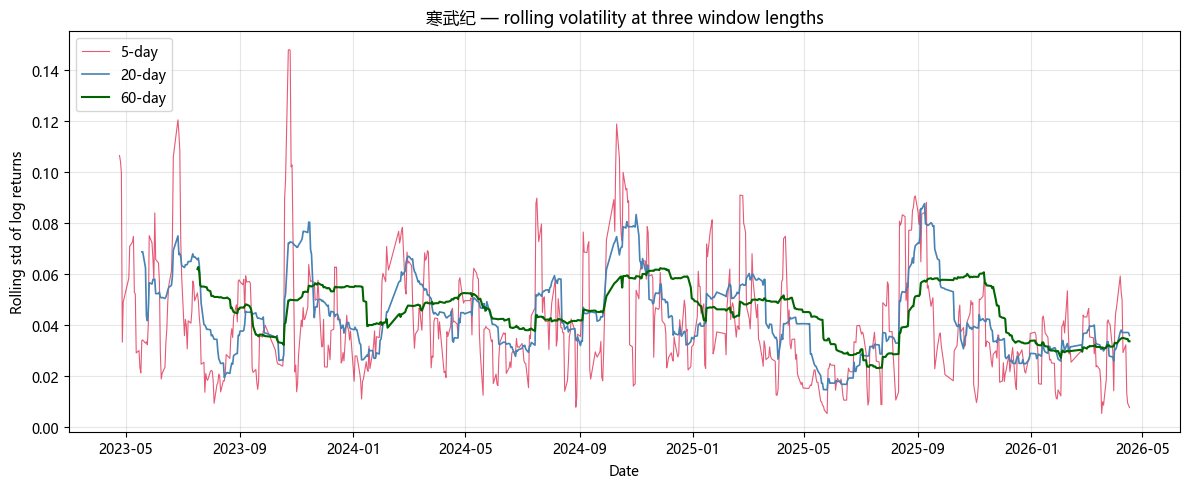

In [11]:
# Compute multiple window lengths on 寒武纪
df["rolling_vol_5"] = df["log_return"].rolling(window=5).std()
df["rolling_vol_20"] = df["log_return"].rolling(window=20).std()  # already computed but harmless to redo
df["rolling_vol_60"] = df["log_return"].rolling(window=60).std()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["rolling_vol_5"],  color="crimson",    linewidth=0.8, alpha=0.7, label="5-day")
ax.plot(df.index, df["rolling_vol_20"], color="steelblue",  linewidth=1.2,            label="20-day")
ax.plot(df.index, df["rolling_vol_60"], color="darkgreen",  linewidth=1.5,            label="60-day")
ax.set_ylabel("Rolling std of log returns")
ax.set_xlabel("Date")
ax.set_title(f"{name} — rolling volatility at three window lengths")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Build returns panels for each basket
# Note: using log returns throughout for consistency

def build_log_returns_panel(data_dict):
    """
    Given a dict of {code: OHLCV DataFrame}, return a wide DataFrame
    of log returns: index = date, columns = codes.
    """
    closes = pd.DataFrame({code: df["close"] for code, df in data_dict.items()})
    log_returns = np.log(closes / closes.shift(1))
    return log_returns

hs300_rets = build_log_returns_panel(hs300_data)
zz1000_rets = build_log_returns_panel(zz1000_data)

print("HS300 panel shape:", hs300_rets.shape)
print("ZZ1000 panel shape:", zz1000_rets.shape)
print("\nFirst 3 rows of HS300 returns:")
print(hs300_rets.head(3))

HS300 panel shape: (727, 5)
ZZ1000 panel shape: (727, 5)

First 3 rows of HS300 returns:
            sh.601211  sh.601995  sh.688256  sz.000876  sh.600522
date                                                             
2023-04-17        NaN        NaN        NaN        NaN        NaN
2023-04-18  -0.005225  -0.006904  -0.005196  -0.009712   0.020898
2023-04-19  -0.011195  -0.011775   0.124784   0.000750  -0.022141


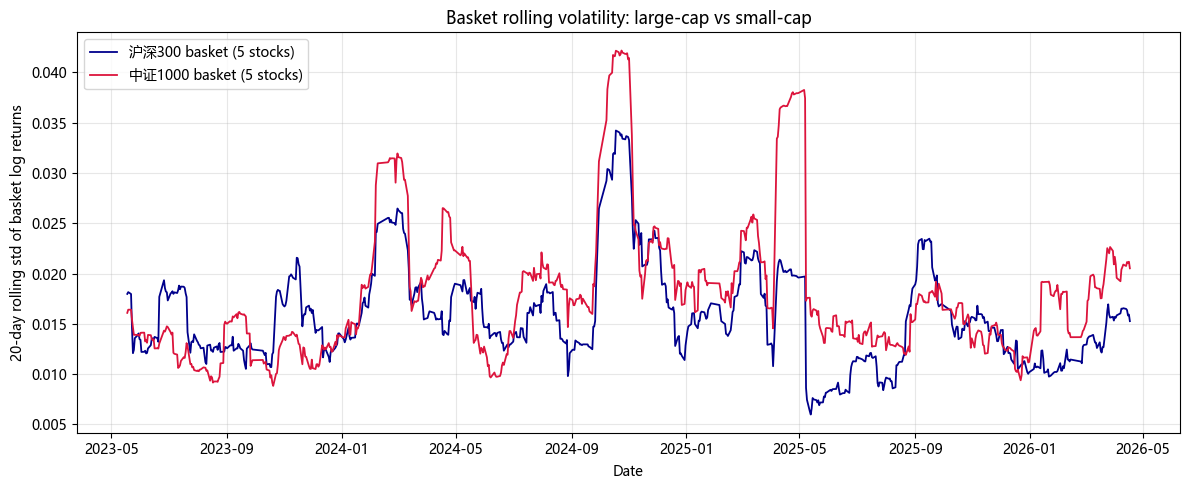

HS300 basket:  mean vol = 0.0157  ann = 24.38%
ZZ1000 basket: mean vol = 0.0179  ann = 27.82%

Max vol dates:
  HS300:  2024-10-18  (0.0342)
  ZZ1000: 2024-10-24  (0.0422)


In [14]:
# Equal-weighted basket returns: row-wise mean across stocks
hs300_basket = hs300_rets.mean(axis=1)
zz1000_basket = zz1000_rets.mean(axis=1)

# 20-day rolling std on each basket
hs300_vol = hs300_basket.rolling(window=20).std()
zz1000_vol = zz1000_basket.rolling(window=20).std()

# Plot on shared axes
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hs300_vol.index,  hs300_vol,  color="darkblue",  linewidth=1.3, label="沪深300 basket (5 stocks)")
ax.plot(zz1000_vol.index, zz1000_vol, color="crimson",   linewidth=1.3, label="中证1000 basket (5 stocks)")
ax.set_ylabel("20-day rolling std of basket log returns")
ax.set_xlabel("Date")
ax.set_title("Basket rolling volatility: large-cap vs small-cap")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics for comparison
print(f"HS300 basket:  mean vol = {hs300_vol.mean():.4f}  ann = {hs300_vol.mean() * np.sqrt(242):.2%}")
print(f"ZZ1000 basket: mean vol = {zz1000_vol.mean():.4f}  ann = {zz1000_vol.mean() * np.sqrt(242):.2%}")
print(f"\nMax vol dates:")
print(f"  HS300:  {hs300_vol.idxmax().date()}  ({hs300_vol.max():.4f})")
print(f"  ZZ1000: {zz1000_vol.idxmax().date()}  ({zz1000_vol.max():.4f})")

In [15]:
# Check what's driving HS300 basket vol in September 2025
# Compute each stock's contribution to the basket return variance in a window
window = hs300_rets.loc["2025-08-15":"2025-10-31"]
print("Per-stock std in Aug-Oct 2025 window:")
print(window.std())

Per-stock std in Aug-Oct 2025 window:
sh.601211    0.014074
sh.601995    0.015962
sh.688256    0.057948
sz.000876    0.012907
sh.600522    0.029178
dtype: float64


In [16]:
# Pull the indexes themselves, treated as single-series instruments
index_codes = {
    "sh.000300": "沪深300",
    "sh.000852": "中证1000",
    "sh.000016": "上证50",       # bonus: even larger-cap than HS300
    "sz.399006": "创业板指",       # bonus: ChiNext growth index
}

index_data = {}
for code, name in index_codes.items():
    print(f"Pulling {code} ({name})...")
    index_data[code] = load_or_fetch(code, START_DATE, END_DATE)
    print(f"  {len(index_data[code])} rows")

Pulling sh.000300 (沪深300)...
login success!
logout success!
  727 rows
Pulling sh.000852 (中证1000)...
login success!
logout success!
  727 rows
Pulling sh.000016 (上证50)...
login success!
logout success!
  727 rows
Pulling sz.399006 (创业板指)...
login success!
logout success!
  727 rows


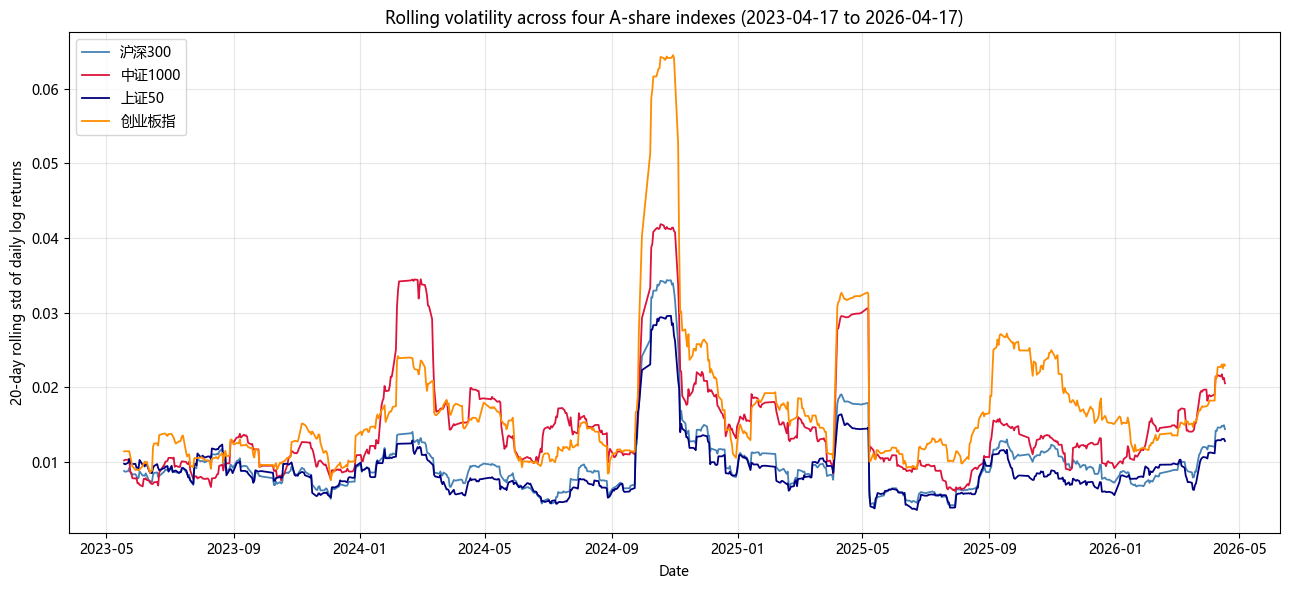


Index        Mean vol     Annualized   Max vol      Min vol     
------------------------------------------------------------
沪深300        0.0097       15.15%       0.0343       0.0037      
中证1000       0.0146       22.77%       0.0418       0.0061      
上证50         0.0090       13.96%       0.0296       0.0035      
创业板指         0.0168       26.16%       0.0645       0.0075      


In [17]:
# Compute log returns and 20-day rolling vol for each index
index_vol = {}
for code, name in index_codes.items():
    df_idx = index_data[code]
    log_ret = np.log(df_idx["close"] / df_idx["close"].shift(1))
    rolling_vol = log_ret.rolling(window=20).std()
    index_vol[name] = rolling_vol

# Plot all four on shared axes
fig, ax = plt.subplots(figsize=(13, 6))
colors = {"上证50": "navy", "沪深300": "steelblue", "中证1000": "crimson", "创业板指": "darkorange"}
for name, vol in index_vol.items():
    ax.plot(vol.index, vol, linewidth=1.3, label=name, color=colors[name])

ax.set_ylabel("20-day rolling std of daily log returns")
ax.set_xlabel("Date")
ax.set_title("Rolling volatility across four A-share indexes (2023-04-17 to 2026-04-17)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
print(f"\n{'Index':<12} {'Mean vol':<12} {'Annualized':<12} {'Max vol':<12} {'Min vol':<12}")
print("-" * 60)
for name, vol in index_vol.items():
    print(f"{name:<12} {vol.mean():<12.4f} {vol.mean()*np.sqrt(242):<12.2%} {vol.max():<12.4f} {vol.min():<12.4f}")